# Guided Numeric Exploration — Undersea Cables & Digital Infrastructure
_Cable × year panel: capacity, chokepoints, redundancy, vulnerability, and faults (2015–2026)_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sergionefedov/undersea-cables-and-global-digital-infrastructure](https://www.kaggle.com/datasets/sergionefedov/undersea-cables-and-global-digital-infrastructure)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Fleet Mix Univariate](#Univariate)** <br>
**4. [Faults and Causes](#Faults)** <br>
**5. [Capacity, Redundancy, Vulnerability](#Capacity)** <br>
**6. [Forward Fault Target](#Target)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A **cable × year** panel (~4,821 rows; ~500 systems; 2015–2026) covering ocean routes, operator types, capacity, chokepoints, burial/redundancy, a computed `vulnerability_index`, and fault flags.

`chokepoint` is null for most rows (non-chokepoint routes) — mapped to an explicit `none` category for plots. `fault_next_year` is NaN on the final year; `vulnerability_index` is computed — treat circular explanations carefully.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "sergionefedov/undersea-cables-and-global-digital-infrastructure"
MASTER = "undersea_cables_master.csv"
EXPECTED_COLS = [
    "year", "cable_id", "ocean_route", "operator_type", "rfs_year", "age_years",
    "fiber_pairs", "length_km", "n_landing_countries", "chokepoint",
    "design_capacity_tbps", "lit_capacity_tbps", "utilization_pct", "protected_burial",
    "design_life_years", "route_redundancy", "is_low_redundancy", "vulnerability_index",
    "fault_cause", "fault_this_year", "fault_next_year",
]


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(MASTER))
        assert hits, f"{MASTER} not under /kaggle/input"
        return hits[0].parent
    local_dir = Path("data") / "undersea-cables"
    if (local_dir / MASTER).exists():
        return local_dir
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(MASTER))
    assert hits, f"expected {MASTER} under {root}"
    return hits[0].parent


root = resolve_dataset_root()
print("Dataset root:", root)
df = pd.read_csv(root / MASTER, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert df["cable_id"].nunique() == 500, df["cable_id"].nunique()
assert df["year"].min() == 2015 and df["year"].max() == 2026
assert df["fault_this_year"].isin([0, 1]).all()

df["chokepoint_label"] = df["chokepoint"].fillna("none")
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Rows:", len(df), "| cables:", df["cable_id"].nunique())
print("Fault rate:", round(df["fault_this_year"].mean(), 3))
print("fault_next_year null share: {:.1%}".format(df["fault_next_year"].isna().mean()))
print("Chokepoint non-null share: {:.1%}".format(df["chokepoint"].notna().mean()))


  0%|          | 0.00/82.8k [00:00<?, ?B/s]

100%|██████████| 82.8k/82.8k [00:00<00:00, 616kB/s]

100%|██████████| 82.8k/82.8k [00:00<00:00, 614kB/s]

Extracting files...


Dataset root: /Users/nicapotato/.cache/kagglehub/datasets/sergionefedov/undersea-cables-and-global-digital-infrastructure/versions/1
Missing Values: 4486
Rows: 4821 | cables: 500
Fault rate: 0.188
fault_next_year null share: 10.4%
Chokepoint non-null share: 17.3%


**Code Explanation and Reasoning:** <br>
Panel schema and 500 cable IDs are asserted. Chokepoint nulls become label `none` for grouping only — the raw column stays null where not applicable. Forward fault nulls are not imputed.


In [3]:
df.sample(5, random_state=7)


,year,cable_id,ocean_route,operator_type,rfs_year,age_years,fiber_pairs,length_km,n_landing_countries,chokepoint,design_capacity_tbps,lit_capacity_tbps,utilization_pct,protected_burial,design_life_years,route_redundancy,is_low_redundancy,vulnerability_index,fault_cause,fault_this_year,fault_next_year,chokepoint_label
4293,2025,CAB0443,EMEA-Asia,hyperscaler,2021,4,22,17715.0,8,Hormuz,898.9,395.8,54.6,0,25,47,0,50.0,none,0,1.0,Hormuz
3713,2025,CAB0384,Trans-Atlantic,consortium,2016,9,7,5041.0,3,NaN,236.0,169.9,100.0,0,25,62,0,30.2,none,0,0.0,none
3481,2022,CAB0361,Trans-Pacific,consortium,2001,21,8,14154.0,4,NaN,98.3,98.3,76.1,0,25,45,0,49.2,none,0,0.0,none
3143,2018,CAB0329,Intra-Europe,consortium,2014,4,9,1659.0,3,NaN,277.7,118.8,52.0,0,25,45,0,22.2,none,0,0.0,none
3238,2019,CAB0338,Intra-Asia,hyperscaler,2009,10,15,6778.0,4,NaN,355.7,305.0,79.2,1,25,64,0,15.9,none,0,0.0,none


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False).head(12))
df[["age_years", "length_km", "lit_capacity_tbps", "utilization_pct", "vulnerability_index"]].describe().T.round(2)


,Column,Unique,Null
9,chokepoint,8,3986
20,fault_next_year,3,500
0,year,12,0
12,utilization_pct,877,0
19,fault_this_year,2,0
18,fault_cause,5,0
17,vulnerability_index,117,0
16,is_low_redundancy,2,0
15,route_redundancy,38,0
14,design_life_years,1,0


,count,mean,std,min,25%,50%,75%,max
age_years,4821.0,11.51,7.21,0.0,5.0,11.0,17.0,28.0
length_km,4821.0,6795.58,4605.59,191.0,2970.0,5750.0,10339.0,19976.0
lit_capacity_tbps,4821.0,200.38,181.33,16.0,73.8,138.9,271.2,1327.0
utilization_pct,4821.0,62.51,23.38,1.0,45.3,62.3,80.4,100.0
vulnerability_index,4821.0,36.74,19.60,0.0,22.2,34.9,48.4,100.0


**Interpretation** <br>
Most cable-years are non-chokepoint. Faults are uncommon but material (~19%). Vulnerability is an engineered index — useful as a summary, not an independent ground truth.


# **3. Fleet Mix Univariate:** <a id="Univariate"></a>


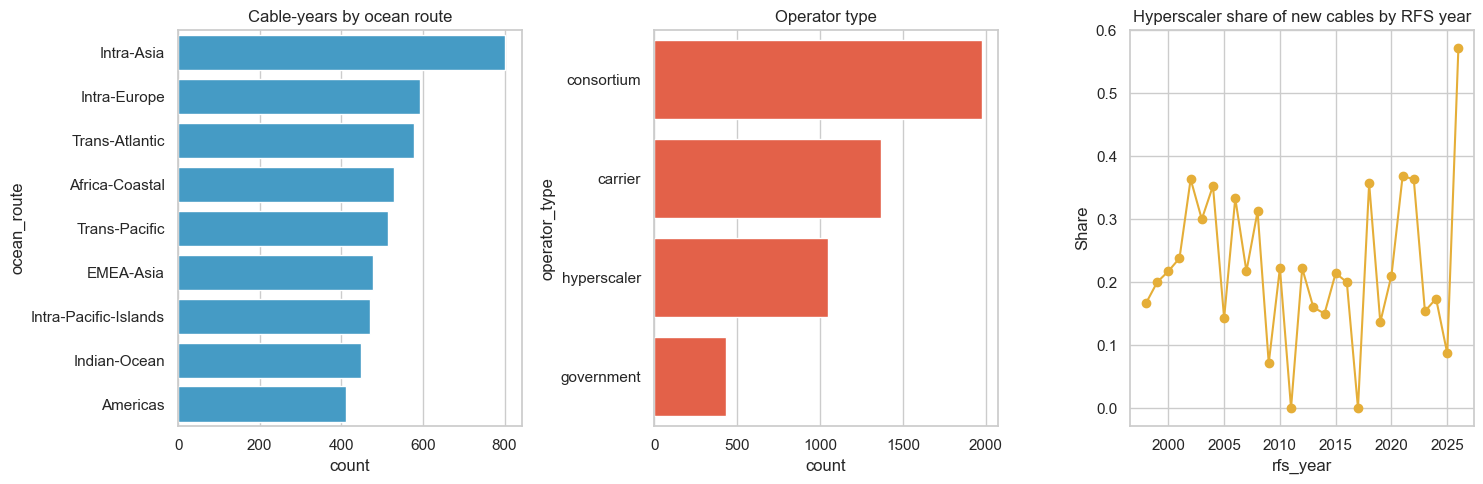

In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, y="ocean_route", order=df["ocean_route"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Cable-years by ocean route")
sns.countplot(data=df, y="operator_type", order=df["operator_type"].value_counts().index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Operator type")
# Hyperscaler share among new RFS by year (reference table grain)
ref = pd.read_csv(root / "cables_reference.csv")
hyp = ref.assign(is_hyper=ref["operator_type"].eq("hyperscaler")).groupby("rfs_year")["is_hyper"].mean()
hyp.plot(ax=ax[2], color="#e5ae38", marker="o")
ax[2].set_title("Hyperscaler share of new cables by RFS year")
ax[2].set_ylabel("Share")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Route and operator bars describe the installed base in the panel. Hyperscaler RFS share asks whether private cloud owners increasingly lay their own systems.


# **4. Faults and Causes:** <a id="Faults"></a>


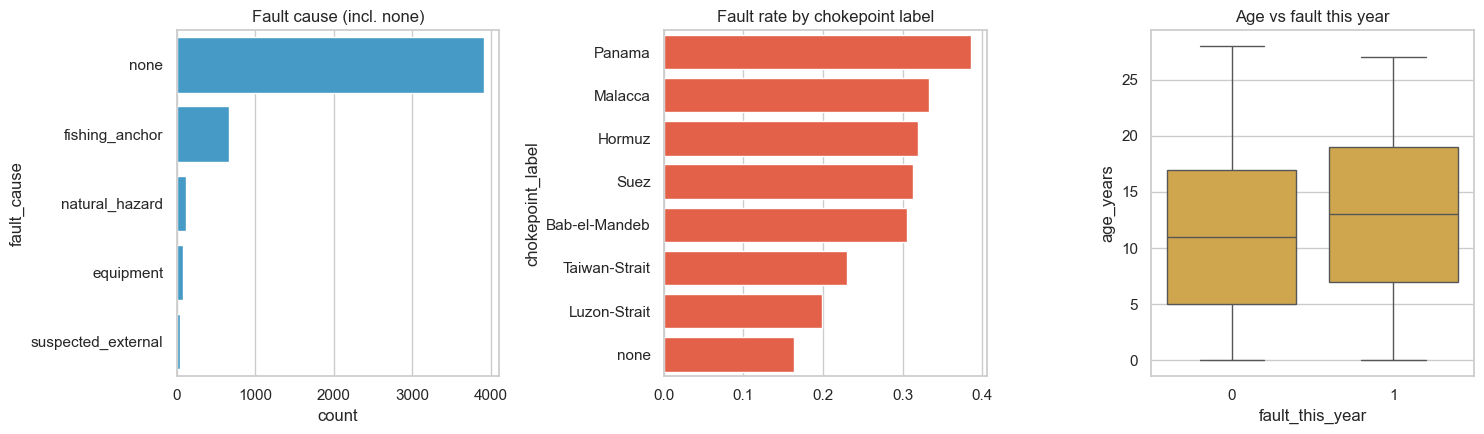

mean  count
protected_burial is_low_redundancy              
0                0                  0.193   1692
                 1                  0.307    600
1                0                  0.144   1838
                 1                  0.190    691

In [6]:
faults = df[df["fault_this_year"] == 1]
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(
    data=df, y="fault_cause",
    order=df["fault_cause"].value_counts().index, ax=ax[0], color="#30a2da",
)
ax[0].set_title("Fault cause (incl. none)")
rate_cp = df.groupby("chokepoint_label")["fault_this_year"].mean().sort_values(ascending=False)
sns.barplot(x=rate_cp.values, y=rate_cp.index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Fault rate by chokepoint label")
sns.boxplot(data=df, x="fault_this_year", y="age_years", ax=ax[2], color="#e5ae38")
ax[2].set_title("Age vs fault this year")
plt.tight_layout()
plt.show()

display(
    df.groupby(["protected_burial", "is_low_redundancy"])["fault_this_year"]
    .agg(["mean", "count"])
    .round(3)
)


**How to Interpret:** <br>
Fishing/anchor should dominate non-`none` causes if the generator matches public fault lore. Chokepoint fault rates need count context; burial × redundancy crosstabs show resilience associations.


# **5. Capacity, Redundancy, Vulnerability:** <a id="Capacity"></a>


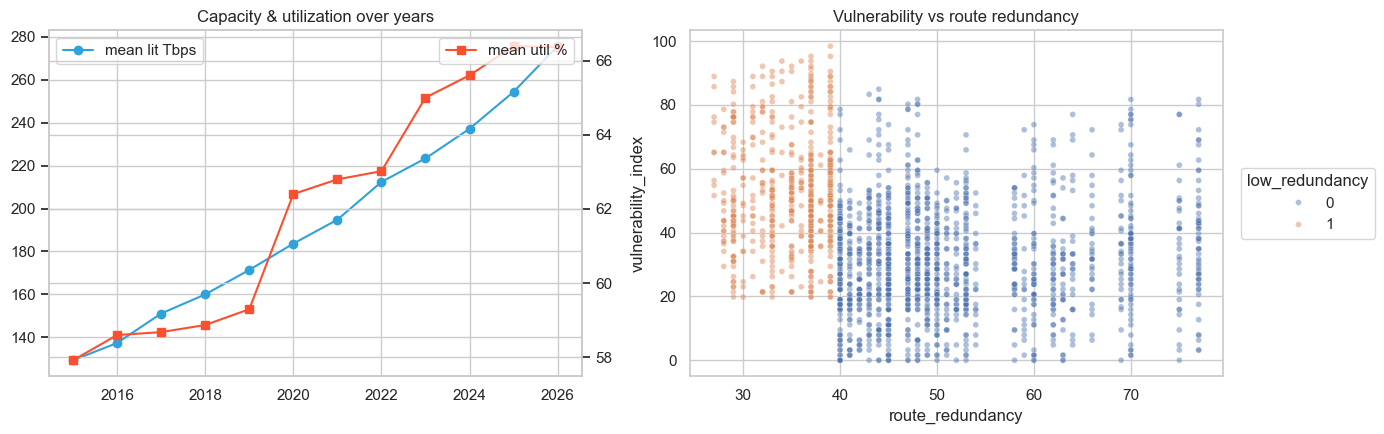

Note: vulnerability_index is COMPUTED — association with redundancy may be partly by construction.


In [7]:
yearly = df.groupby("year").agg(
    mean_lit=("lit_capacity_tbps", "mean"),
    mean_util=("utilization_pct", "mean"),
    fault_rate=("fault_this_year", "mean"),
    n=("cable_id", "count"),
)
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(yearly.index, yearly["mean_lit"], color="#30a2da", marker="o", label="mean lit Tbps")
ax0b = ax[0].twinx()
ax0b.plot(yearly.index, yearly["mean_util"], color="#fc4f30", marker="s", label="mean util %")
ax[0].set_title("Capacity & utilization over years")
ax[0].legend(loc="upper left")
ax0b.legend(loc="upper right")

sns.scatterplot(
    data=df.sample(min(2000, len(df)), random_state=7),
    x="route_redundancy", y="vulnerability_index",
    hue="is_low_redundancy", ax=ax[1], alpha=0.45, s=18,
)
ax[1].set_title("Vulnerability vs route redundancy")
ax[1].legend(title="low_redundancy", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()
print("Note: vulnerability_index is COMPUTED — association with redundancy may be partly by construction.")


**How to Interpret:** <br>
Lit capacity rising with utilization tells a demand/build story. Vulnerability–redundancy scatter is expected to slope if the index embeds redundancy — flag that circularity.


# **6. Forward Fault Target:** <a id="Target"></a>


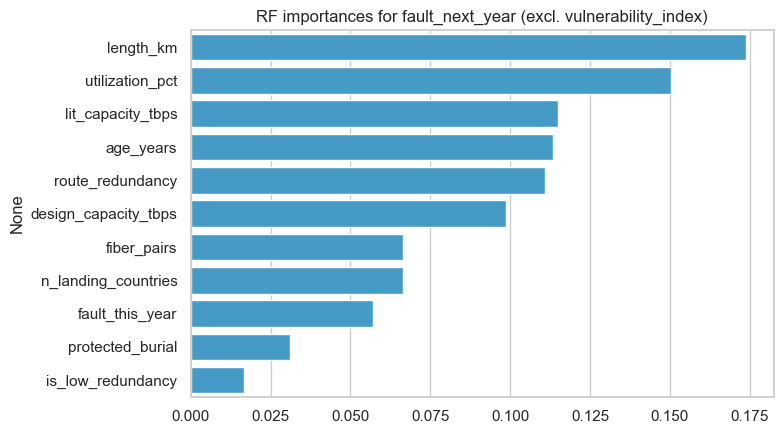

Base rate: 0.19 | in-sample accuracy: 0.832


In [8]:
ml = df[df["fault_next_year"].notna()].copy()
ml["fault_next_year"] = ml["fault_next_year"].astype(int)
feat = [
    "age_years", "fiber_pairs", "length_km", "n_landing_countries",
    "design_capacity_tbps", "lit_capacity_tbps", "utilization_pct",
    "protected_burial", "route_redundancy", "is_low_redundancy", "fault_this_year",
]
X = ml[feat]
y = ml["fault_next_year"]
rf = RandomForestClassifier(n_estimators=300, random_state=7, n_jobs=-1, max_depth=8)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF importances for fault_next_year (excl. vulnerability_index)")
plt.tight_layout()
plt.show()
print("Base rate:", round(y.mean(), 3), "| in-sample accuracy:", round(rf.score(X, y), 3))


**How to Interpret:** <br>
`vulnerability_index` is excluded so importances are not dominated by a computed score. In-sample accuracy is exploratory only — not a deployment metric.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A cable-year infrastructure panel with faults, chokepoints, and engineered vulnerability.

**Working takeaways:** <br>
- Map chokepoint nulls to `none`; do not impute faults.
- Hyperscaler build-out and fault causes are first-class stories.
- Treat `vulnerability_index` as derived.

**Open follow-ups:** <br>
- Survival models for time-to-fault by cable.
- Chokepoint scenario stress (share of lit capacity exposed).
